In [33]:
import pandas as pd


In [34]:
appointments = pd.read_csv('Data/KaggleV2-May-2016.csv')
insurance= pd.read_csv('Data/insurance.csv')
diabetes = pd.read_csv('Data/diabetes.csv')

In [35]:
appointments.head(), insurance.head(), diabetes.head()

(      PatientId  AppointmentID Gender          ScheduledDay  \
 0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
 1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
 2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
 3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
 4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   
 
          AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
 0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
 1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
 2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
 3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
 4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   
 
    Diabetes  Alcoholism  Handcap  SMS_received No-show  
 0         0           0        0             0      No  
 1         0          

In [36]:
appointments.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [37]:
insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [38]:
diabetes.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [39]:
appointments.dtypes

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object

In [40]:
insurance.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [41]:
diabetes.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [42]:
'''Data Cleaning Steps for appointments Dataset'''
"""Column names messy → rename.

“No-show” column has "Yes"/"No" → convert to binary.

Dates are text → convert to datetime.

Age has outliers (negative values) → clean."""

'Column names messy → rename.\n\n“No-show” column has "Yes"/"No" → convert to binary.\n\nDates are text → convert to datetime.\n\nAge has outliers (negative values) → clean.'

In [43]:
# Rename columns for easier handling
appointments.rename(columns=lambda x: x.strip().replace("-", "_"), inplace=True)

In [44]:
# Convert No-show column to binary
appointments["No_show"] = appointments["No_show"].map({"Yes":1, "No":0})

In [45]:
# Convert date columns
appointments["ScheduledDay"] = pd.to_datetime(appointments["ScheduledDay"])
appointments["AppointmentDay"] = pd.to_datetime(appointments["AppointmentDay"])


In [46]:
# Remove negative/invalid ages
appointments = appointments[(appointments["Age"] >= 0) & (appointments["Age"] <= 100)]

In [47]:
# Add weekday column
appointments["Weekday"] = appointments["AppointmentDay"].dt.day_name()

In [48]:
appointments.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No_show,Weekday
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,Friday
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,Friday
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,Friday
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,Friday
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,Friday


In [49]:
""""Convert categorical fields to lowercase (smoker, region, sex).

Create BMI category for better analysis."""

'"Convert categorical fields to lowercase (smoker, region, sex).\n\nCreate BMI category for better analysis.'

In [50]:
#convert categorical fields to lowercase
insurance["smoker"] = insurance["smoker"].str.lower()
insurance["region"] = insurance["region"].str.lower()
insurance["sex"]=insurance["sex"].str.lower()

In [51]:
# Create BMI category
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 25:
        return "Normal"
    elif 25 <= bmi < 30:
        return "Overweight"
    else:
        return "Obese"

insurance["bmi_category"] = insurance["bmi"].apply(bmi_category)

In [52]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


In [53]:
"""Check for missing values.

Standardize column names.
Feature engineering e.g., group pregnancies into ranges."""

'Check for missing values.\n\nStandardize column names.\nFeature engineering e.g., group pregnancies into ranges.'

In [54]:
# Clean column names
diabetes.rename(columns=lambda x: x.strip().replace(" ", "_").lower(), inplace=True)

In [55]:

# Replace zero values with NaN where not possible (like glucose, blood pressure)
cols_with_zero_invalid = ["glucose", "bloodpressure", "bmi"]
for col in cols_with_zero_invalid:
    diabetes[col] = diabetes[col].replace(0, pd.NA)

In [56]:
# Handle missing values (simple impute with median)
diabetes.fillna(diabetes.median(), inplace=True)

C:\Users\rushi\AppData\Local\Temp\ipykernel_19680\886552182.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diabetes.fillna(diabetes.median(), inplace=True)


In [83]:
# Group pregnancies
diabetes["pregnancy_group"] = pd.cut(diabetes["pregnancies"], bins=[-1,0,2,5,10,20], labels=["0","1-2","3-5","6-10","10+"])

In [82]:
diabetes.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148.0,72.0,35,0,33.6,0.627,50,1
1,1,85.0,66.0,29,0,26.6,0.351,31,0
2,8,183.0,64.0,0,0,23.3,0.672,32,1
3,1,89.0,66.0,23,94,28.1,0.167,21,0
4,0,137.0,40.0,35,168,43.1,2.288,33,1


In [59]:
appointments.to_csv("./data/clean_appointments.csv", index=False)
insurance.to_csv("./data/clean_insurance.csv", index=False)
diabetes.to_csv("./data/clean_diabetes.csv", index=False)


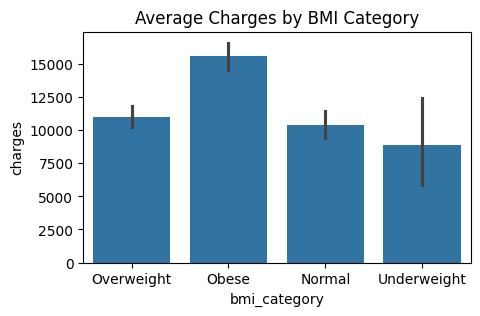

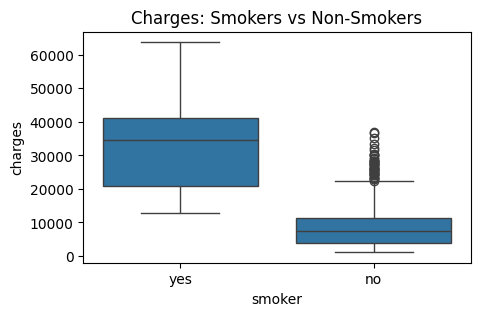

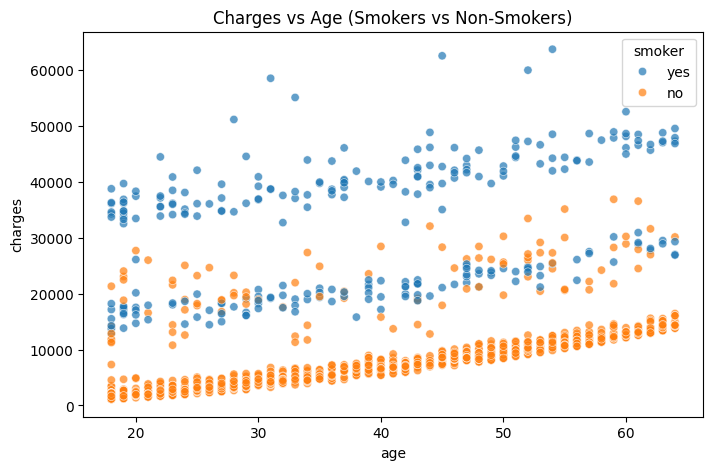

In [66]:
#insurance dataset EDA

# Charges by BMI category
plt.figure(figsize=(5,3))
sns.barplot(x="bmi_category", y="charges", data=insurance)
plt.title("Average Charges by BMI Category")
plt.show()

# Charges by smoker
plt.figure(figsize=(5,3))
sns.boxplot(x="smoker", y="charges", data=insurance)
plt.title("Charges: Smokers vs Non-Smokers")
plt.show()

# Charges by age
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="charges", hue="smoker", data=insurance, alpha=0.7)
plt.title("Charges vs Age (Smokers vs Non-Smokers)")
plt.show()


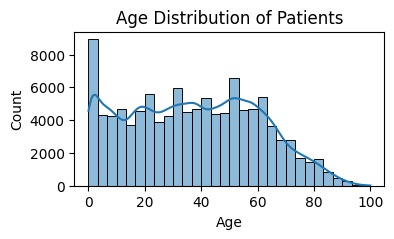

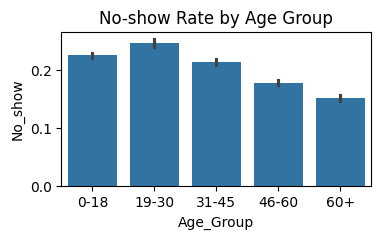

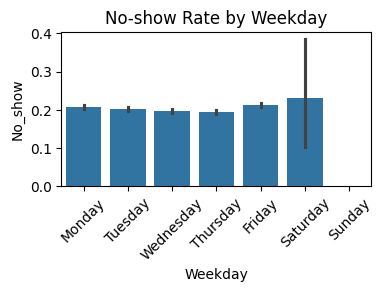

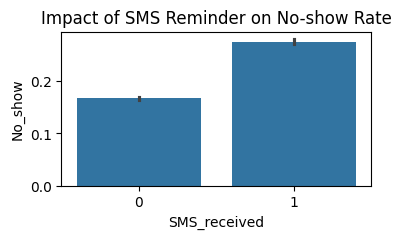

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt


#appointments dataset EDA

# Distribution of ages
plt.figure(figsize=(4,2))
sns.histplot(appointments["Age"], bins=30, kde=True)
plt.title("Age Distribution of Patients")
plt.show()

# No-show rate by age group
plt.figure(figsize=(4,2))
appointments["Age_Group"] = pd.cut(appointments["Age"], bins=[0,18,30,45,60,100],labels=["0-18","19-30","31-45","46-60","60+"])
sns.barplot(x="Age_Group", y="No_show", data=appointments)
plt.title("No-show Rate by Age Group")
plt.show()

# No-show rate by weekday
plt.figure(figsize=(4,2))
sns.barplot(x="Weekday", y="No_show", data=appointments, order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("No-show Rate by Weekday")
plt.xticks(rotation=45)
plt.show()

# Effect of SMS reminders
plt.figure(figsize=(4,2))
sns.barplot(x="SMS_received", y="No_show", data=appointments)
plt.title("Impact of SMS Reminder on No-show Rate")
plt.show()


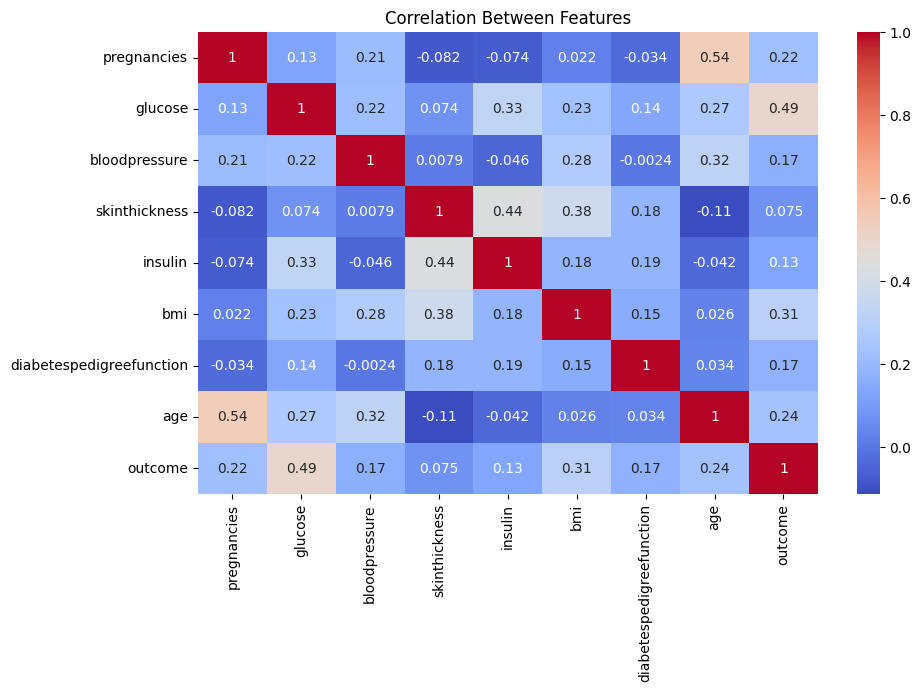

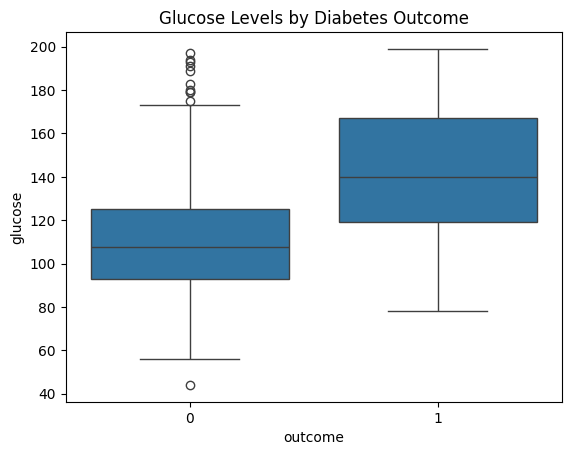

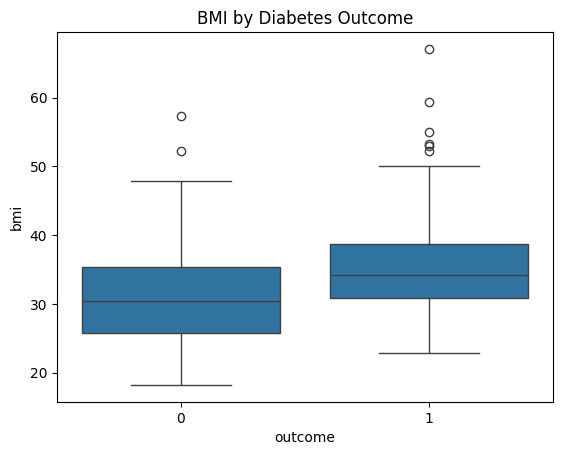

In [86]:
#Diabetes dataset EDA
diabetes= diabetes.select_dtypes(include=['number'])

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(diabetes.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Features")
plt.show()

# Glucose levels by diabetes outcome
sns.boxplot(x="outcome", y="glucose", data=diabetes)
plt.title("Glucose Levels by Diabetes Outcome")
plt.show()

# BMI by outcome
sns.boxplot(x="outcome", y="bmi", data=diabetes)
plt.title("BMI by Diabetes Outcome")
plt.show()



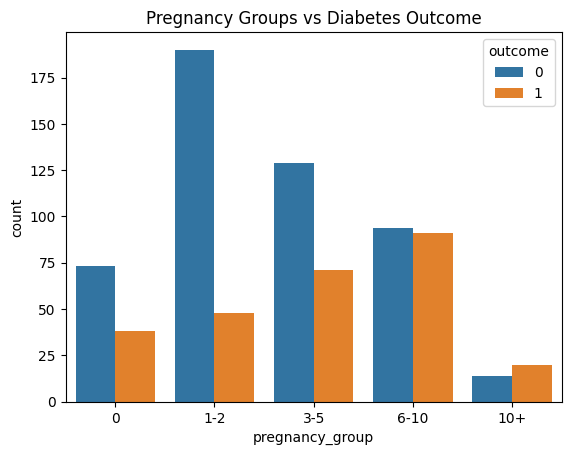

In [84]:
# Pregnancies by outcome
sns.countplot(x="pregnancy_group", hue="outcome", data=diabetes)
plt.title("Pregnancy Groups vs Diabetes Outcome")
plt.show()


In [87]:
appointments.groupby("Weekday")["No_show"].mean().to_csv("./data/insights_no_show_by_weekday.csv")
insurance.groupby("bmi_category")["charges"].mean().to_csv("./data/insights_charges_by_bmi.csv")
diabetes.groupby("pregnancy_group")["outcome"].mean().to_csv("./data/insights_diabetes_by_pregnancy.csv")


KeyError: 'pregnancy_group'